# Regression Analysis: Steps 1 & 2

**Module 6: Correlation Analysis** | Lean Six Sigma Data Analytics

---

## The Four Steps of Regression

Remember that regression analysis consists of four steps.

In this video, we will explain how to perform the **first two steps**:
1. **Fitted line plot** - Visualize the data
2. **Main regression analysis** - Test significance and strength

You will learn how to make a fitted line plot, perform the main regression analysis, and interpret the output.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for regression analysis!')

Ready for regression analysis!


---

## The Tea Bag Example

In the previous video, we were wondering if the number of production stops was related to the number of broken tea bags.

| Variable | Description | Type |
|----------|-------------|------|
| Y (CTQ) | Number of broken tea bags | Numerical |
| X | Number of production stops | Numerical |

Both are numerical, hence we need to perform a **regression analysis** to test if there is a relationship.

In [2]:
# Load the data
def load_teabags():
    df = pd.read_excel(xlsx, sheet_name='Tea bags', skiprows=7)
    return df.dropna()

teabags = load_teabags()

print('TEA BAG DATA')
print('=' * 40)
print()
print('Columns:')
print('  Day - The day number')
print('  Bags - Number of defect bags')
print('  Stops - Number of production stops')
print()
print(teabags)

TEA BAG DATA

Columns:
  Day - The day number
  Bags - Number of defect bags
  Stops - Number of production stops

    Day  Bags  Stops
0     1    16      5
1     2    21      8
2     3    15      4
3     4    20      6
4     5    20      8
5     6    13      5
6     7    22      7
7     8    21      7
8     9    18      7
9    10    25      9
10   11    18      6
11   12    18      6
12   13    13      3
13   14    26      9
14   15    23      9
15   16     6      0
16   17    13      4
17   18    21      7
18   19    18      7
19   20    21      8
20   21    18      6
21   22    17      6
22   23    16      4
23   24    19      7
24   25    21      7


---

## Step 1: Fitted Line Plot

First, we have to make a fitted line plot and study the data.

In Minitab: **Stat > Regression > Fitted Line Plot**
- Response (Y): Bags
- Predictor (X): Stops

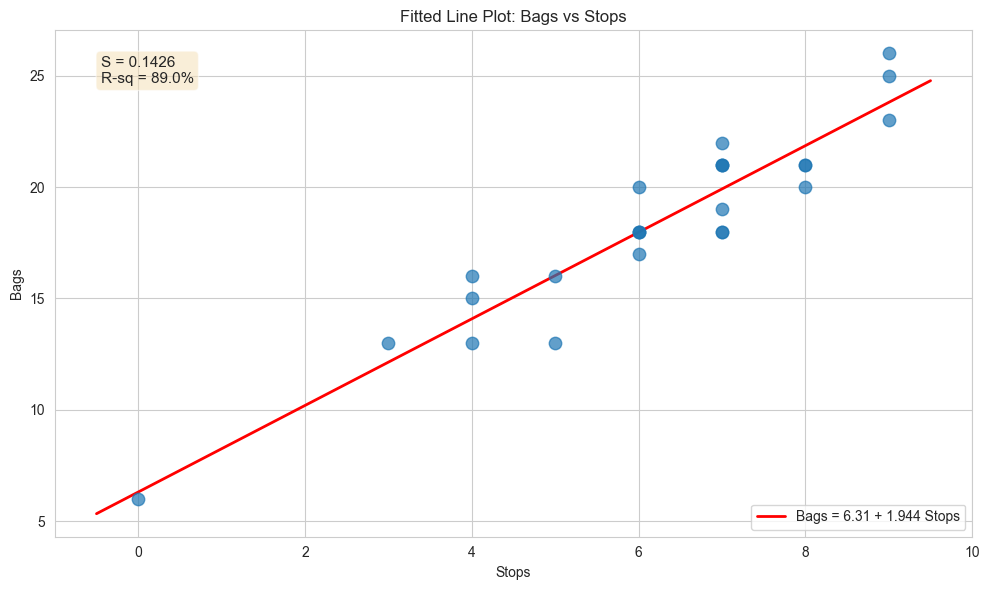

In [3]:
# Perform regression
x = teabags['Stops'].values
y = teabags['Bags'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

# Create fitted line plot
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(x, y, s=80, alpha=0.7, zorder=3)

# Fitted line
x_line = np.array([x.min() - 0.5, x.max() + 0.5])
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'Bags = {intercept:.2f} + {slope:.3f} Stops')

ax.set_xlabel('Stops')
ax.set_ylabel('Bags')
ax.set_title('Fitted Line Plot: Bags vs Stops')
ax.legend()

# Add regression stats to plot
stats_text = f'S = {std_err:.4f}\nR-sq = {r_squared:.1%}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

---

## Understanding the Fitted Line Formula

The formula for the fitted line is:

$$Y = a + bX$$

or in our case:

$$\text{Bags} = a + b \times \text{Stops}$$

In [4]:
print('THE FITTED LINE FORMULA')
print('=' * 60)
print()
print(f'Bags = {intercept:.2f} + {slope:.3f} × Stops')
print()
print('Interpreting the coefficients:')
print('-' * 40)
print()
print(f'a (constant) = {intercept:.2f}')
print(f'  → This is the value when X equals 0')
print(f'  → With 0 stops, we still expect {intercept:.1f} defects')
print()
print(f'b (slope) = {slope:.3f}')
print(f'  → This is the steepness of the line')
print(f'  → If stops increases by 1, broken tea bags increases by {slope:.3f}')

THE FITTED LINE FORMULA

Bags = 6.31 + 1.944 × Stops

Interpreting the coefficients:
----------------------------------------

a (constant) = 6.31
  → This is the value when X equals 0
  → With 0 stops, we still expect 6.3 defects

b (slope) = 1.944
  → This is the steepness of the line
  → If stops increases by 1, broken tea bags increases by 1.944


---

## Step 2: Main Regression Analysis

We still have to determine if these findings are due to **chance** or if they are a **structural effect**.

This is step 2: the main part of the regression analysis.

In [5]:
print('REGRESSION ANALYSIS OUTPUT')
print('=' * 60)
print()
print(f'P-value: {p_value:.4f}')
print(f'R-squared: {r_squared:.1%}')
print()
print('-' * 60)

REGRESSION ANALYSIS OUTPUT

P-value: 0.0000
R-squared: 89.0%

------------------------------------------------------------


---

## Interpreting the P-value

P-values are part of **hypothesis tests**:

| Hypothesis | Statement |
|------------|----------|
| **H₀ (null)** | There is NO significant relationship between the two variables |
| **H₁ (alternative)** | There IS a significant relationship |

**Decision rule:**
- If p-value < 0.05 → Reject H₀, support H₁ (significant relationship)
- If p-value ≥ 0.05 → Cannot reject H₀ (results may be due to chance or not enough data)

In [6]:
print('P-VALUE INTERPRETATION')
print('=' * 60)
print()
print(f'P-value = {p_value:.4f}')
print()
if p_value < 0.05:
    print('P-value < 0.05')
    print()
    print('CONCLUSION:')
    print('  The null hypothesis can be REJECTED.')
    print('  The alternative hypothesis can be SUPPORTED.')
    print()
    print('  There IS a significant relationship between Stops and Bags.')
else:
    print('P-value >= 0.05')
    print()
    print('CONCLUSION:')
    print('  Results are either due to chance or not enough data.')

P-VALUE INTERPRETATION

P-value = 0.0000

P-value < 0.05

CONCLUSION:
  The null hypothesis can be REJECTED.
  The alternative hypothesis can be SUPPORTED.

  There IS a significant relationship between Stops and Bags.


---

## Interpreting R-squared

R-squared tells us **how strong** the relationship is.

| R-squared | Interpretation |
|-----------|---------------|
| High (close to 100%) | X is a strong predictor of Y ("big fish") |
| Low | Much variation in Y remains unexplained ("small fish") |

In [7]:
print('R-SQUARED INTERPRETATION')
print('=' * 60)
print()
print(f'R-squared = {r_squared:.1%}')
print()
print('This is quite large!')
print()
print('MEANING:')
print(f'  The number of production stops explains {r_squared:.0%} of the')
print('  variation in broken tea bags.')
print()
print('  Stops is a STRONG predictor for defect bags.')
print('  The influence factor Stops is a BIG FISH.')

R-SQUARED INTERPRETATION

R-squared = 89.0%

This is quite large!

MEANING:
  The number of production stops explains 89% of the
  variation in broken tea bags.

  Stops is a STRONG predictor for defect bags.
  The influence factor Stops is a BIG FISH.


---

## Examples: Guessing P-value and R-squared

Can you guess what the p-value and R-squared would look like for these four graphs?

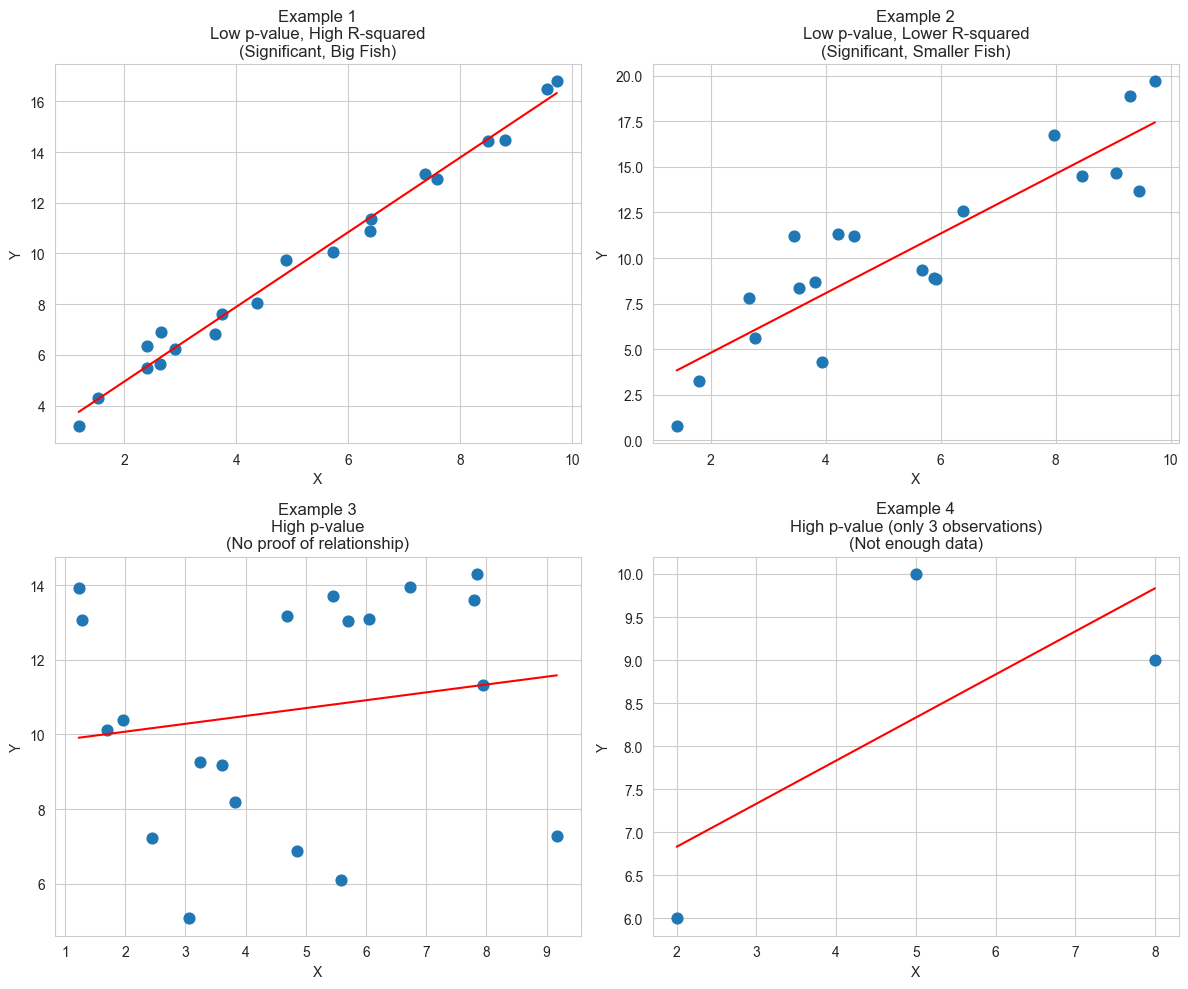

INTERPRETATION:

Top Left:  Low p-value, very high R-squared → Significant, BIG FISH
Top Right: Low p-value, smaller R-squared → Significant, but SMALLER FISH
           (Data more spread around line, more unexplained variation)
Bottom Left:  High p-value → No proof of relationship, R-squared has no meaning
Bottom Right: High p-value due to lack of data (only 3 observations)


In [8]:
# Four example scenarios
np.random.seed(42)
n = 20

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Example 1: Low p-value, high R-squared (big fish)
x1 = np.random.uniform(1, 10, n)
y1 = 2 + 1.5*x1 + np.random.normal(0, 0.5, n)
axes[0, 0].scatter(x1, y1, s=60)
z = np.polyfit(x1, y1, 1)
axes[0, 0].plot(np.sort(x1), np.poly1d(z)(np.sort(x1)), 'r-')
axes[0, 0].set_title('Example 1\nLow p-value, High R-squared\n(Significant, Big Fish)')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')

# Example 2: Low p-value, lower R-squared (smaller fish)
x2 = np.random.uniform(1, 10, n)
y2 = 2 + 1.5*x2 + np.random.normal(0, 3, n)
axes[0, 1].scatter(x2, y2, s=60)
z = np.polyfit(x2, y2, 1)
axes[0, 1].plot(np.sort(x2), np.poly1d(z)(np.sort(x2)), 'r-')
axes[0, 1].set_title('Example 2\nLow p-value, Lower R-squared\n(Significant, Smaller Fish)')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Y')

# Example 3: High p-value, no relationship
x3 = np.random.uniform(1, 10, n)
y3 = np.random.uniform(5, 15, n)
axes[1, 0].scatter(x3, y3, s=60)
z = np.polyfit(x3, y3, 1)
axes[1, 0].plot(np.sort(x3), np.poly1d(z)(np.sort(x3)), 'r-')
axes[1, 0].set_title('Example 3\nHigh p-value\n(No proof of relationship)')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')

# Example 4: High p-value due to lack of data (only 3 points)
x4 = np.array([2, 5, 8])
y4 = np.array([6, 10, 9])
axes[1, 1].scatter(x4, y4, s=60)
z = np.polyfit(x4, y4, 1)
axes[1, 1].plot(np.sort(x4), np.poly1d(z)(np.sort(x4)), 'r-')
axes[1, 1].set_title('Example 4\nHigh p-value (only 3 observations)\n(Not enough data)')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')

plt.tight_layout()
plt.show()

print('INTERPRETATION:')
print()
print('Top Left:  Low p-value, very high R-squared → Significant, BIG FISH')
print('Top Right: Low p-value, smaller R-squared → Significant, but SMALLER FISH')
print('           (Data more spread around line, more unexplained variation)')
print('Bottom Left:  High p-value → No proof of relationship, R-squared has no meaning')
print('Bottom Right: High p-value due to lack of data (only 3 observations)')

---

## Using the Formula for Predictions

Minitab computed the formula for us - the **transfer function**.

You can use this formula to make predictions.

In [9]:
print('PREDICTION EXAMPLE')
print('=' * 60)
print()
print(f'Formula: Bags = {intercept:.2f} + {slope:.3f} × Stops')
print()
print('Question: How many defects do you expect if we reduce')
print('          the number of production stops to 3?')
print()
stops_new = 3
prediction = intercept + slope * stops_new
print(f'Answer: Bags = {intercept:.2f} + {slope:.3f} × {stops_new}')
print(f'        Bags = {prediction:.1f}')
print()
print(f'We expect approximately {prediction:.0f} defects.')
print('(This is the expected average.)')

PREDICTION EXAMPLE

Formula: Bags = 6.31 + 1.944 × Stops

Question: How many defects do you expect if we reduce
          the number of production stops to 3?

Answer: Bags = 6.31 + 1.944 × 3
        Bags = 12.1

We expect approximately 12 defects.
(This is the expected average.)


In [10]:
print('PREDICTION LIMITATION')
print('=' * 60)
print()
print('Question: What is your prediction for 25 production stops?')
print()
print('Answer: WE CANNOT ANSWER THIS QUESTION!')
print()
print(f'Our X data only goes from {x.min()} to {x.max()}.')
print('25 is FAR OUTSIDE of this range.')
print()
print('Therefore, we cannot make a reliable prediction for 25 stops.')

PREDICTION LIMITATION

Question: What is your prediction for 25 production stops?

Answer: WE CANNOT ANSWER THIS QUESTION!

Our X data only goes from 0 to 9.
25 is FAR OUTSIDE of this range.

Therefore, we cannot make a reliable prediction for 25 stops.


---

## Summary

We discussed **Steps 1 and 2** of regression analysis.

### Step 1: Fitted Line Plot

The fitted line plot shows:
- **a (constant):** The value when X = 0
- **b (slope):** How much Y changes when X increases by 1

### Step 2: Main Regression Analysis

| Output | What it tells you |
|--------|------------------|
| **P-value** | Are the findings due to chance or a structural effect? |
| **R-squared** | How strong is the relationship? (Big fish vs small fish) |

Steps 3 and 4 are explained in the next videos.